6CS012 Worksheet 1 – Review on Python Programming and NumPy for Deep Learning
Name: Chirag Lama
Student ID: 2434743
Module: 6CS012 – Artificial Intelligence and Machine Learning

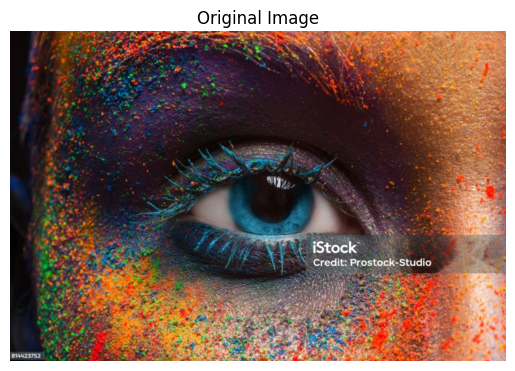

In [7]:
# Load and Display image
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image
image = Image.open("/content/drive/MyDrive/Level 6 AI ML/eye.png")

# Convert to numpy array
img_array = np.array(image)

# Display original image
plt.imshow(img_array)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


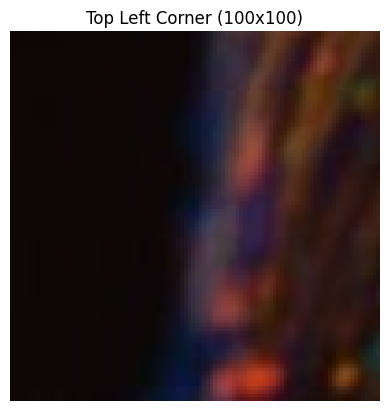

In [9]:
# Show top left 100x100 pixels
top_left = img_array[0:100, 0:100]

plt.imshow(top_left)
plt.title("Top Left Corner (100x100)")
plt.axis("off")
plt.show()

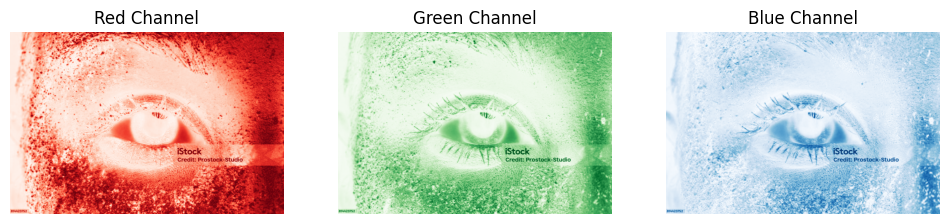

In [10]:
# Show RGB CHANNEL
red = img_array[:,:,0]
green = img_array[:,:,1]
blue = img_array[:,:,2]

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(red, cmap="Reds")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(green, cmap="Greens")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(blue, cmap="Blues")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

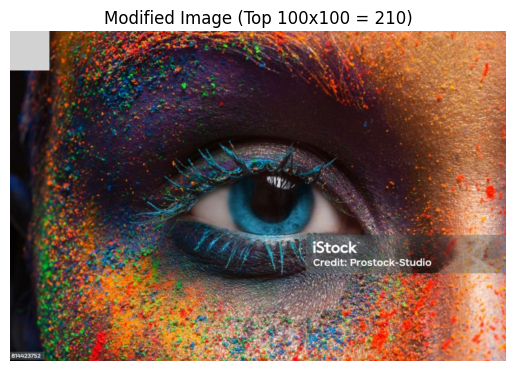

In [11]:
# Modify top left 100x100 pixels
modified = img_array.copy()

# change pixel value
modified[0:100,0:100] = 210

plt.imshow(modified)
plt.title("Modified Image (Top 100x100 = 210)")
plt.axis("off")
plt.show()

EXERCISE 2 - GRAYSCALE IMAGE

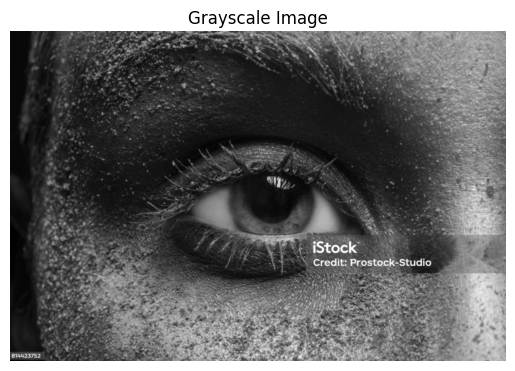

In [13]:
# load gray scale image
gray_image = Image.open("/content/drive/MyDrive/Level 6 AI ML/eye.png").convert("L")

gray_array = np.array(gray_image)

plt.imshow(gray_array, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

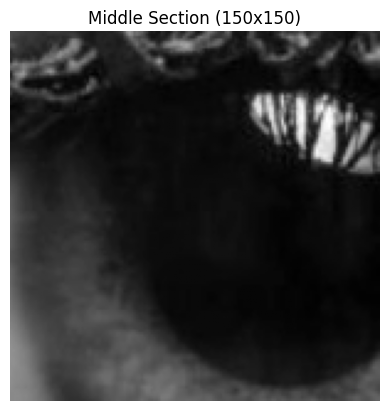

In [14]:
# extract middle 150 pixels
h, w = gray_array.shape

center = gray_array[h//2-75:h//2+75, w//2-75:w//2+75]

plt.imshow(center, cmap="gray")
plt.title("Middle Section (150x150)")
plt.axis("off")
plt.show()

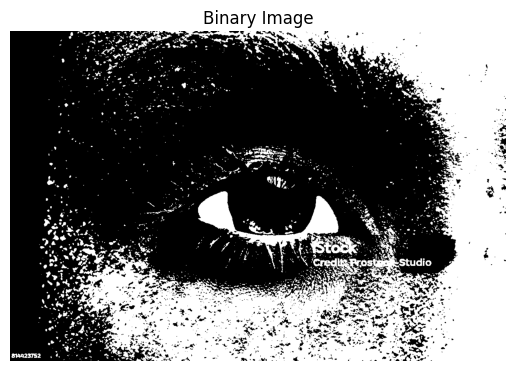

In [15]:
# Apply threshold
binary = gray_array.copy()

binary[binary < 100] = 0
binary[binary >= 100] = 255

plt.imshow(binary, cmap="gray")
plt.title("Binary Image")
plt.axis("off")
plt.show()

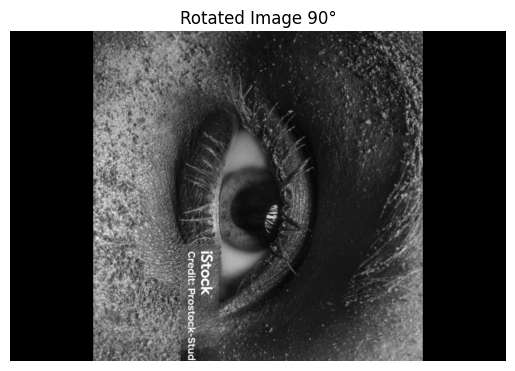

In [16]:
# Rotate image
rotated = gray_image.rotate(-90)

plt.imshow(rotated, cmap="gray")
plt.title("Rotated Image 90°")
plt.axis("off")
plt.show()

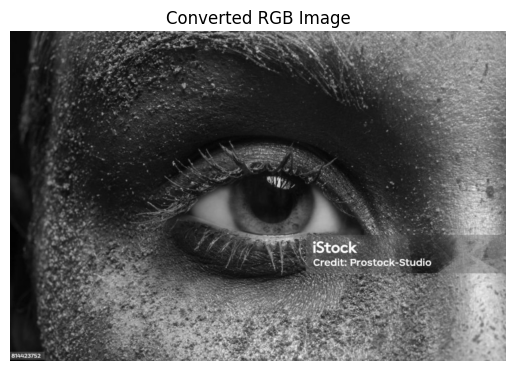

In [17]:
# Convert gray scale to RGB
rgb_image = np.stack((gray_array,)*3, axis=-1)

plt.imshow(rgb_image)
plt.title("Converted RGB Image")
plt.axis("off")
plt.show()

EXERCISE 3 - PCA compression

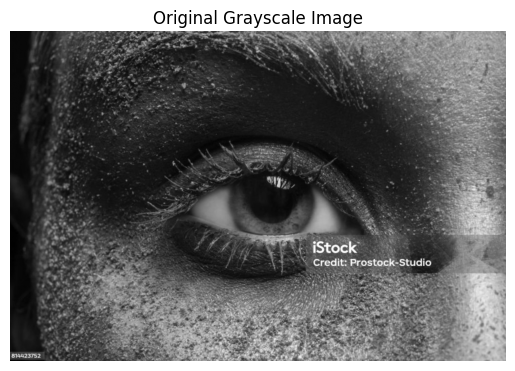

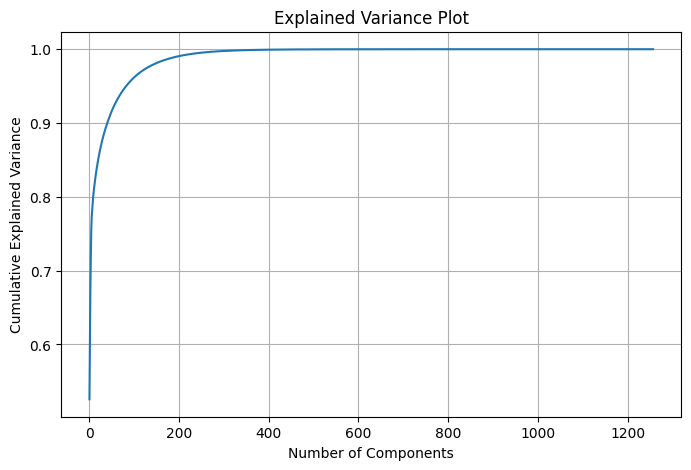

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image in grayscale
image = Image.open("/content/drive/MyDrive/Level 6 AI ML/eye.png").convert("L")

# Convert image to numpy array
image_array = np.array(image)

# Display original grayscale image
plt.imshow(image_array, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

# Get dimensions
height, width = image_array.shape

# Prepare data
data = image_array.reshape(height, width)

# Compute mean
mean = np.mean(data, axis=0)

# Center the data
centered_data = data - mean

# Compute covariance matrix
cov_matrix = np.cov(centered_data, rowvar=False)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues and eigenvectors in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

# Explained variance
explained_variance = eigenvalues / np.sum(eigenvalues)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.grid(True)
plt.show()

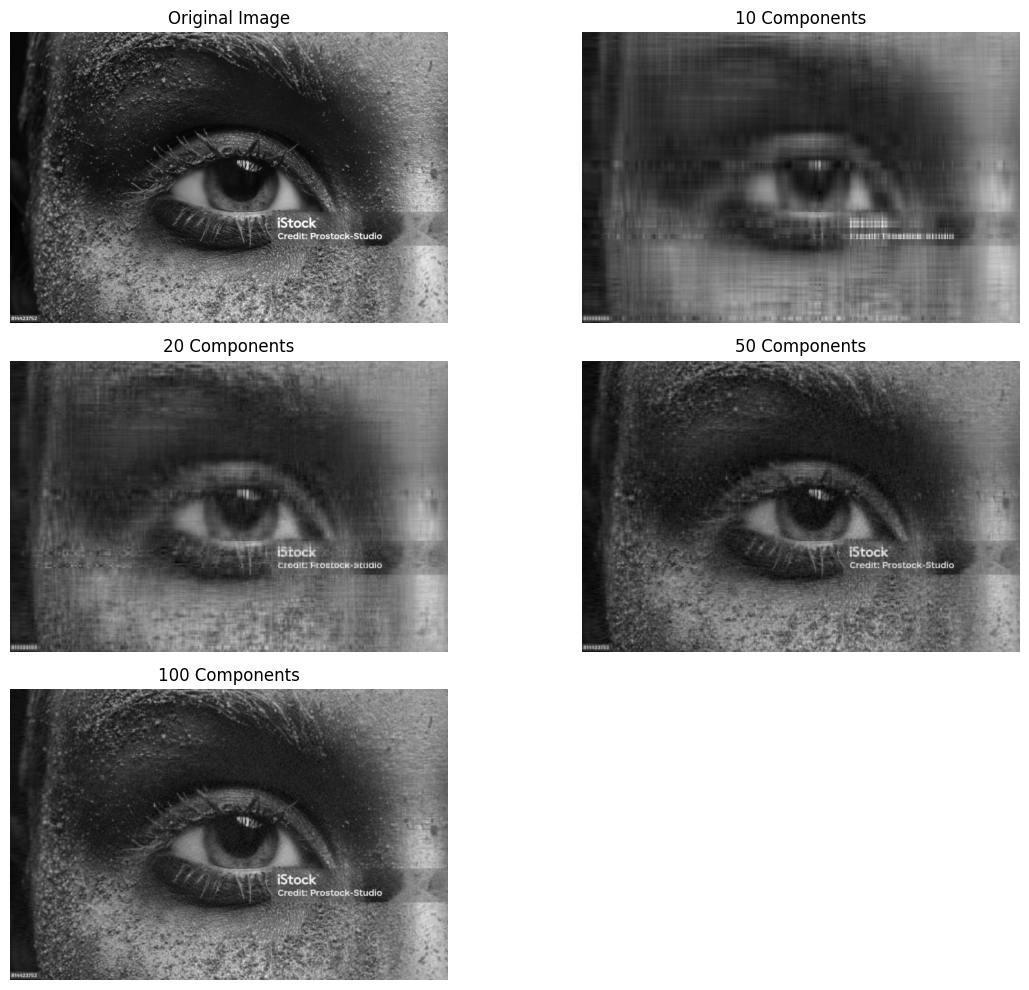

In [20]:
components_list = [10, 20, 50, 100]

plt.figure(figsize=(12,10))

# Original image
plt.subplot(3,2,1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

for i, k in enumerate(components_list, start=2):
    components = eigenvectors[:, :k]

    # Compress
    compressed_data = np.dot(centered_data, components)

    # Reconstruct
    reconstructed_data = np.dot(compressed_data, components.T) + mean

    plt.subplot(3,2,i)
    plt.imshow(reconstructed_data, cmap="gray")
    plt.title(f"{k} Components")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Choose one k value to save
k = 50
components = eigenvectors[:, :k]

compressed_data = np.dot(centered_data, components)
reconstructed_data = np.dot(compressed_data, components.T) + mean

# Convert to valid image format
reconstructed_image = Image.fromarray(np.uint8(np.clip(reconstructed_data, 0, 255)))

# Save image
reconstructed_image.save("/content/pca_reconstructed_50.png")

print("Saved as /content/pca_reconstructed_50.png")

Saved as /content/pca_reconstructed_50.png


In [26]:
# Compute covariance matrix
cov_matrix = np.cov(centered_data, rowvar=False)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# sort eigenvalues
sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

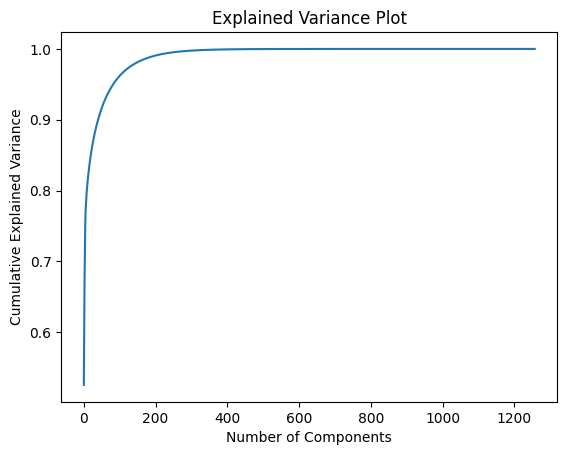

In [25]:
# ADD eigenvalues
explained_variance = eigenvalues / np.sum(eigenvalues)

plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance Plot")
plt.show()